In [2]:
import kagglehub
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import StratifiedShuffleSplit
from pandas.plotting import scatter_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR # remember it doesnt scale well to big data sets
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, reciprocal
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
import os

c:\Users\jubel\REPON\Machine-Learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyboardInterrupt: 

In [ ]:
# Download latest version
path = kagglehub.dataset_download("nehalbirla/vehicle-dataset-from-cardekho")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\jubel\.cache\kagglehub\datasets\nehalbirla\vehicle-dataset-from-cardekho\versions\4


In [ ]:
csv_path = os.path.join(path, "car data.csv")  #path is the folder, car data.csv is the file. They need to be joined to create a complete search path 
cars_full = pd.read_csv(csv_path)

## Frame the problem - look at the big picture

we need predict how much used cars can be sold for, in order to know for example if it is worth it to fix it up. How much would we make of cars, based on some information about it.

Without a prediction model, the experienced car salesmen and machanics would be the experts to consult for this problem. The model could maybe save time for them. Since the model will be trained on lots of data it will hopefully be able to predict even better than them. 

since we have one data set that we will no be updating, it will be an offline model. It is also supervised, since we have the labels, i think. And since we want to predict values - that makes it a regerssion task, ha! Multiple regression, since we have several features.

Perfomance measure - RMSE is the typical performance measure for regression problems. Gives an idea of how much error the system typically makes in its predictions, with a higher weight given to large errors. 

In [ ]:
cars_full.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
cars_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [ ]:
cars_full["Fuel_Type"].value_counts()

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

might be a problem that there are so few of CNG. Maybe it should be removed?

In [ ]:
cars_full["Seller_Type"].value_counts()

Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64

In [ ]:
cars_full["Transmission"].value_counts()

Transmission
Manual       261
Automatic     40
Name: count, dtype: int64

Quite few of Automatic..

In [ ]:
cars_full["Owner"].value_counts()

Owner
0    290
1     10
3      1
Name: count, dtype: int64

The car that has had 3 owners is an obvious outlier, I think we can remove it. 

In [ ]:
cars_full.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


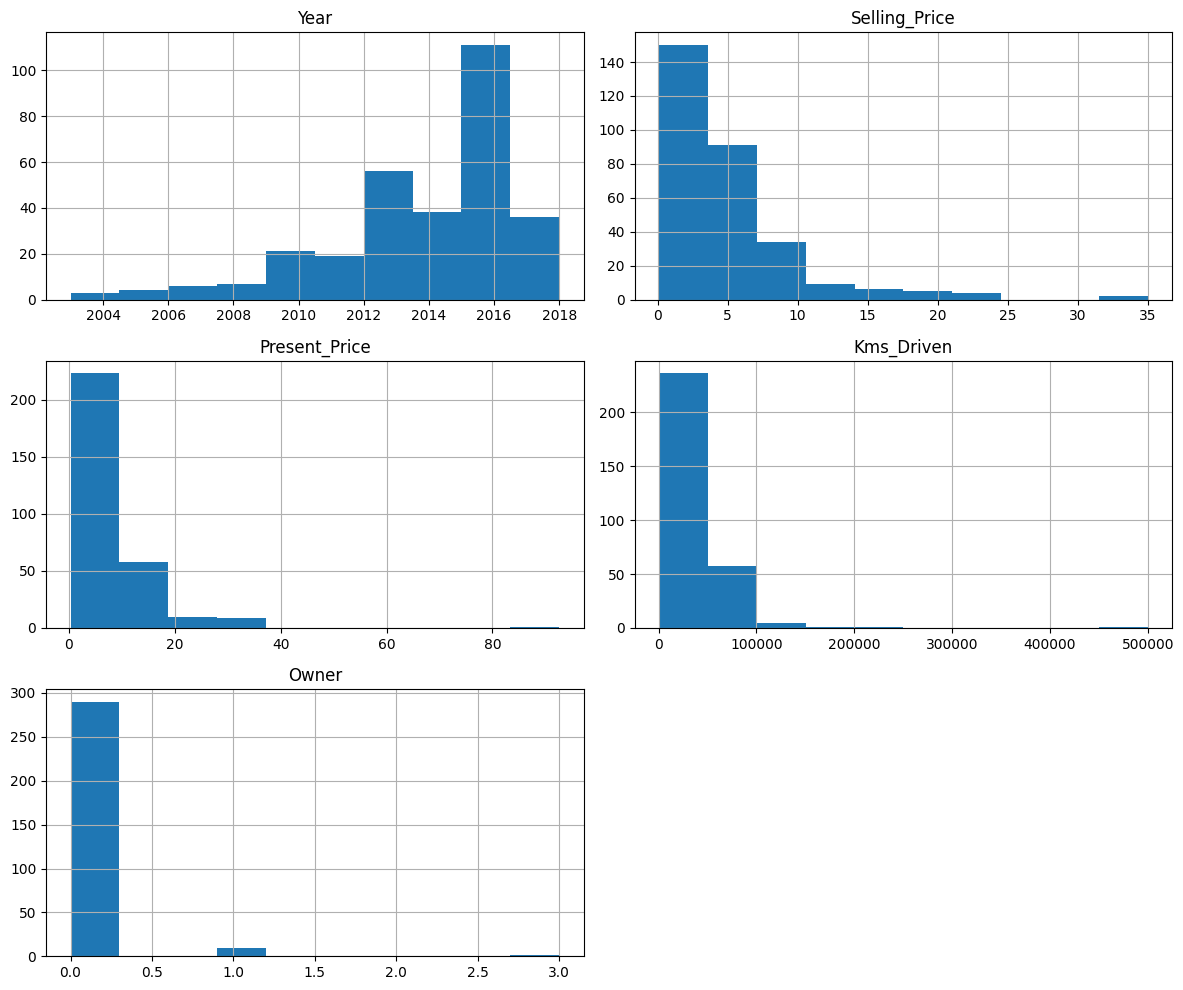

In [ ]:
cars_full.hist(figsize=(12,10))
plt.tight_layout()

Our goals is to predict the selling price of a used car

Present price - is what a new car would cost atm

Prices are scaled obviously

Attributes have very different scales

## Ok let's create a test set (but first stratifying samples)

We can use the row index as a unique identifier! 

We have a lot of categorical attributes, some categories have very few values... -- this we think about AFTER creating test set. The test set SHOULD mirror real world data. 

Do we need to do stratified sampling for any important attribute, like the book did with median income?

We have a very small data set... if we do random sampling, we might introduce sampling bias... Wich ones should we stratify..? 

Let's stratify on 
- Car age
- Fuel type 
- Transmission 

They are important, have uneven distributions and would distort the test set if sampled randomly. 


In [ ]:
cars_full["Year"].value_counts().sort_index()

Year
2003     2
2004     1
2005     4
2006     4
2007     2
2008     7
2009     6
2010    15
2011    19
2012    23
2013    33
2014    38
2015    61
2016    50
2017    35
2018     1
Name: count, dtype: int64

We transform Years into Age, because that is more important information here

In [ ]:
cars_full["Age"]  = 2020 - cars_full["Year"]

cars_full["Age_bin"] = pd.cut(cars_full["Age"], bins=[0,3,6,10,20], labels=False)



NameError: name 'cars_full' is not defined